# Evaluasi PaddleOCR

In [1]:
!pip install paddlepaddle==3.1.0 -q
!pip install paddleocr==3.1.0 -q
!pip install datasets==4.3.0 jiwer pillow numpy -q
!pip uninstall langchain -y
!pip uninstall paddlex -y
!pip install paddlex==3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
import re
import json
import os
import numpy as np
from jiwer import cer, wer
from datasets import load_dataset

In [3]:
DATASET_NAME  = "Teklia/IAM-line"
DATASET_SPLIT = "test[:500]"

dataset = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
print(f"Dataset loaded: {len(dataset)} samples")

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

Dataset loaded: 500 samples


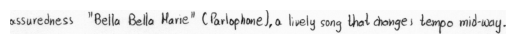

GT: assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .


In [4]:
sample = dataset[0]

sample["image"].save("temp.jpg")
sample["image"]

import matplotlib.pyplot as plt

plt.imshow(sample["image"], cmap="gray")
plt.axis("off")
plt.show()
ground_truth = sample["text"]
print("GT:", ground_truth)

def normalize_text(text):
    text = text.strip()
    text = text.replace("\n", " ")
    text = re.sub(r" +", " ", text)
    text = text.lower()
    return text

In [5]:
from paddleocr import PaddleOCR

print("[PaddleOCR] Loading...")
ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv5_mobile_det",
    text_recognition_model_name="PP-OCRv5_mobile_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False)

print("PaddleOCR loaded ✓")

[PaddleOCR] Loading...


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_mobile_det', None)
Using official model (PP-OCRv5_mobile_det), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.
Encounter exception when download model from huggingface: 
Server disconnected without sending a response..
PaddleX would try to download from BOS.
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/official_inference_model/paddle3.0.0/PP-OCRv5_mobile_det_infer.tar ...
[==================================================] 100.00%
Extracting PP-OCRv5_mobile_det_infer.tar
[==================================================] 100.00%
Creating model: ('PP-OCRv5_mobile_rec', None)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR loaded ✓


In [6]:
import numpy as np

def run_ocr(image):
    img = np.array(image)  # 🔥 WAJIB: convert ke numpy

    result = ocr.predict(img)

    if not result:
        return ""

    res = result[0]
    texts = res.get("rec_texts", [])

    return " ".join(texts)

In [7]:
os.makedirs("./results", exist_ok=True)

total_cer = 0
total_wer = 0

print("Mulai evaluasi PaddleOCR...")

for i, sample in enumerate(dataset):

    gt   = normalize_text(sample["text"])
    pred = normalize_text(run_ocr(sample["image"].convert("RGB")))

    if not gt.strip():   gt   = " "
    if not pred.strip(): pred = " "

    total_cer += cer(gt, pred)
    total_wer += wer(gt, pred)

    print(f"Done {i+1}/{len(dataset)}")

Mulai evaluasi PaddleOCR...
Done 1/500
Done 2/500
Done 3/500
Done 4/500
Done 5/500
Done 6/500
Done 7/500
Done 8/500
Done 9/500
Done 10/500
Done 11/500
Done 12/500
Done 13/500
Done 14/500
Done 15/500
Done 16/500
Done 17/500
Done 18/500
Done 19/500
Done 20/500
Done 21/500
Done 22/500
Done 23/500
Done 24/500
Done 25/500
Done 26/500
Done 27/500
Done 28/500
Done 29/500
Done 30/500
Done 31/500
Done 32/500
Done 33/500
Done 34/500
Done 35/500
Done 36/500
Done 37/500
Done 38/500
Done 39/500
Done 40/500
Done 41/500
Done 42/500
Done 43/500
Done 44/500
Done 45/500
Done 46/500
Done 47/500
Done 48/500
Done 49/500
Done 50/500
Done 51/500
Done 52/500
Done 53/500
Done 54/500
Done 55/500
Done 56/500
Done 57/500
Done 58/500
Done 59/500
Done 60/500
Done 61/500
Done 62/500
Done 63/500
Done 64/500
Done 65/500
Done 66/500
Done 67/500
Done 68/500
Done 69/500
Done 70/500
Done 71/500
Done 72/500
Done 73/500
Done 74/500
Done 75/500
Done 76/500
Done 77/500
Done 78/500
Done 79/500
Done 80/500
Done 81/500
Done 82/5

In [8]:
avg_cer = total_cer / len(dataset)
avg_wer = total_wer / len(dataset)

print("\n" + "="*50)
print("=== PaddleOCR PP-OCRv5 RESULT ===")
print(f"CER : {avg_cer:.4f}")
print(f"WER : {avg_wer:.4f}")
print("="*50)

results = {
    "model":       "PaddleOCR-PP-OCRv5",
    "dataset":     DATASET_NAME,
    "split":       DATASET_SPLIT,
    "num_samples": len(dataset),
    "avg_cer":     avg_cer,
    "avg_wer":     avg_wer,
}

with open("./results/paddleocr_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved ke ./results/paddleocr_results.json")


=== PaddleOCR PP-OCRv5 RESULT ===
CER : 0.4000
WER : 0.7501
Saved ke ./results/paddleocr_results.json
